In [ ]:
!pip install -q transformers

In [ ]:
from transformers import RobertaTokenizerFast, TFRobertaForSequenceClassification, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I hate you"]
sentiment_pipeline(data)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998656511306763},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079}]

In [ ]:
# download pre-trained emotion classification model
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

emotion(data)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'joy', 'score': 0.9687249660491943},
 {'label': 'anger', 'score': 0.6728214025497437}]

In [ ]:
df = pd.read_csv('SummitWar.csv')

In [ ]:
df.head(5)

,web-scraper-order,web-scraper-start-url,link,link-href,comment
0,1735059353-31,https://transcripts.foreverdreaming.org/viewfo...,11x385 - Arriving at Halfway Through the Grand...,https://transcripts.foreverdreaming.org/viewto...,Hold Land of Marie Jois\n\nBartholomew Kuma-sa...
1,1735059356-32,https://transcripts.foreverdreaming.org/viewfo...,11x386 - Hatred of the Straw Hat Crew – Enter ...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...
2,1735059359-33,https://transcripts.foreverdreaming.org/viewfo...,11x387 - The Fated Reunion! Save the Imprisone...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...
3,1735059362-34,https://transcripts.foreverdreaming.org/viewfo...,11x388 - Tragedy! The Truth of the Unmasked Duval,https://transcripts.foreverdreaming.org/viewto...,During their voyage in search of Fishman Islan...
4,1735059364-35,https://transcripts.foreverdreaming.org/viewfo...,11x389 - expl*si*n! The Sunny's Super Secret w...,https://transcripts.foreverdreaming.org/viewto...,"On the way to their next destination, Fishman ..."


In [ ]:
df.drop(['web-scraper-order', 'web-scraper-start-url'], axis=1, inplace=True)

In [ ]:
df.head(5)

,link,link-href,comment
0,11x385 - Arriving at Halfway Through the Grand...,https://transcripts.foreverdreaming.org/viewto...,Hold Land of Marie Jois\n\nBartholomew Kuma-sa...
1,11x386 - Hatred of the Straw Hat Crew – Enter ...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...
2,11x387 - The Fated Reunion! Save the Imprisone...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...
3,11x388 - Tragedy! The Truth of the Unmasked Duval,https://transcripts.foreverdreaming.org/viewto...,During their voyage in search of Fishman Islan...
4,11x389 - expl*si*n! The Sunny's Super Secret w...,https://transcripts.foreverdreaming.org/viewto...,"On the way to their next destination, Fishman ..."


In [ ]:
MAX_LENGTH = 512  # ขีดจำกัดของโมเดล
df['comment'] = df['comment'].apply(lambda x: x[:MAX_LENGTH] if isinstance(x, str) else "")
#ตัดข้อความให้สั้นลงก่อนประมวลผล

In [ ]:
df['comment'] = df['comment'].str.replace('\n', '').str.replace('\r', '').str.replace('', '')

In [ ]:
df['sentiment'] = df.comment.apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [ ]:
df['emotion'] = df.comment.apply(lambda x: emotion(x)[0]['label'])

In [ ]:
df.head(5)

,link,link-href,comment,sentiment,emotion
0,11x385 - Arriving at Halfway Through the Grand...,https://transcripts.foreverdreaming.org/viewto...,Hold Land of Marie JoisBartholomew Kuma-sama h...,NEGATIVE,anger
1,11x386 - Hatred of the Straw Hat Crew – Enter ...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...,NEGATIVE,surprise
2,11x387 - The Fated Reunion! Save the Imprisone...,https://transcripts.foreverdreaming.org/viewto...,As Luffy and his friends continued their voyag...,POSITIVE,surprise
3,11x388 - Tragedy! The Truth of the Unmasked Duval,https://transcripts.foreverdreaming.org/viewto...,During their voyage in search of Fishman Islan...,POSITIVE,joy
4,11x389 - expl*si*n! The Sunny's Super Secret w...,https://transcripts.foreverdreaming.org/viewto...,"On the way to their next destination, Fishman ...",POSITIVE,surprise


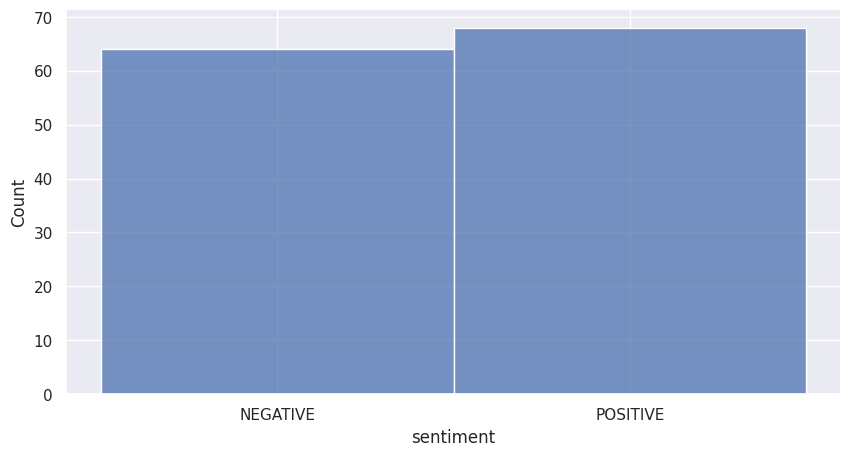

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['sentiment'])

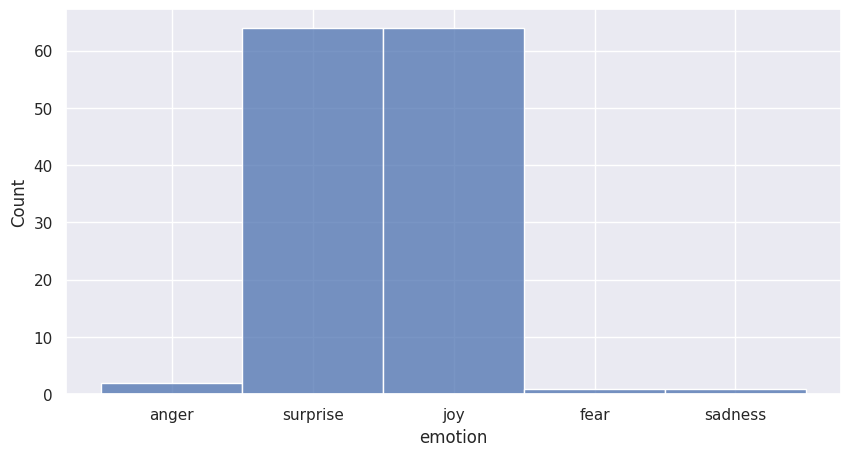

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['emotion'])

In [ ]:
df.to_csv('SoothingRelaxation-done.csv', index=False)

In [ ]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

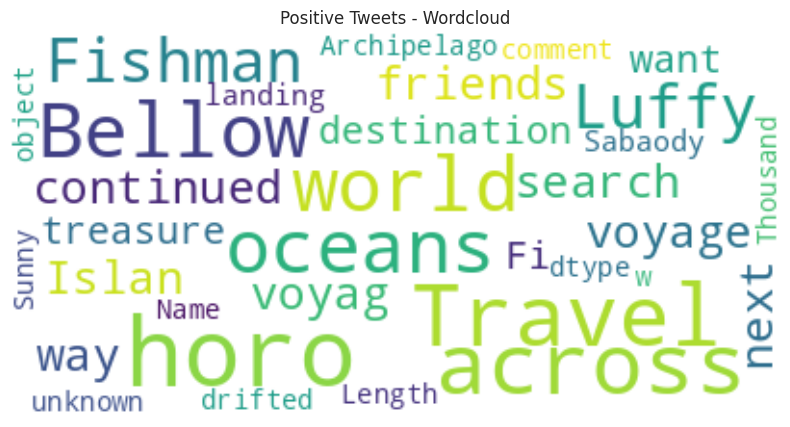

In [ ]:
# Wordcloud with positive
msg = df['comment'][df["sentiment"] == 'POSITIVE']
stop_words = list(STOPWORDS)
positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Positive Tweets - Wordcloud")
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


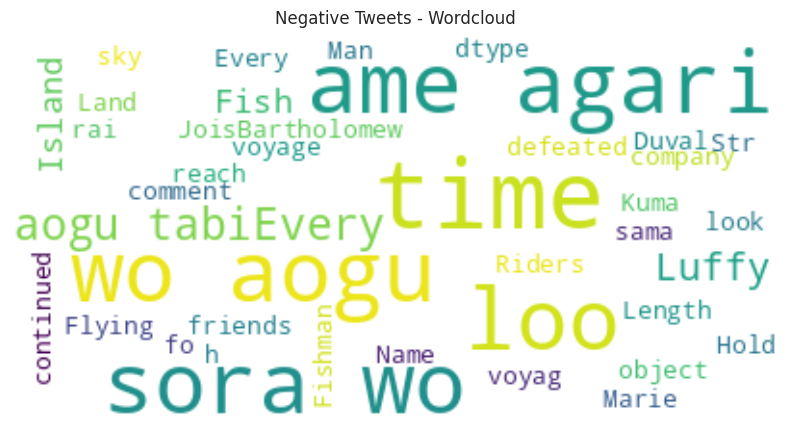

In [ ]:
 # Wordcloud with negative
msg = df['comment'][df["sentiment"] == 'NEGATIVE']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


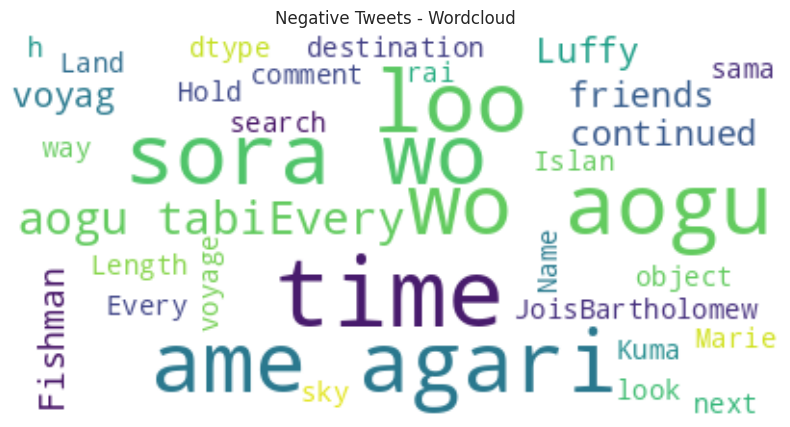

In [ ]:
msg = df['comment']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


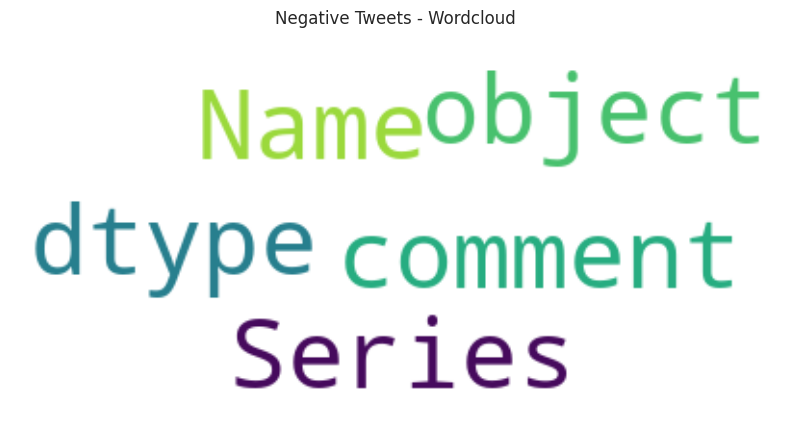

In [ ]:
msg = df['comment'][df['emotion'] == 'JOY']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
